In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.parser import cargar_todos

# Configuracion visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Carga
facturas = cargar_todos('../data/raw')
print(f"Facturas cargadas: {len(facturas)}")

Facturas cargadas: 68514


In [2]:
registros = []
for f in facturas:
    for item in f.items:
        registros.append({
            'factura': f.numero,
            'fecha': f.fecha,
            'dia_semana': f.dia_semana,
            'producto': item.producto,
            'cantidad': item.cantidad,
            'precio_unitario': item.precio_unitario,
            'subtotal': item.subtotal
        })

df = pd.DataFrame(registros)
df['fecha'] = pd.to_datetime(df['fecha'])
print(f"Total line-items: {len(df)}")
df.head()

Total line-items: 147413


,factura,fecha,dia_semana,producto,cantidad,precio_unitario,subtotal
0,23102,2024-03-10,domingo,BRISA LIMON-MANZANA 600ML,1.0,2521.01,2521.0
1,23102,2024-03-10,domingo,TIC TAC 16GR,1.0,1848.74,1849.0
2,49554,2024-03-10,domingo,VIVE 100 LITRO,1.0,2941.18,2941.0
3,49554,2024-03-10,domingo,LUCKY GIN X 10,1.0,4873.95,4874.0
4,49555,2024-03-10,domingo,CRISTAL ALOE 330 ML,1.0,2184.87,2185.0


In [3]:
total_registros = len(df)
total_facturas = df['factura'].nunique()
items_por_factura = df.groupby('factura')['producto'].count()

print("=" * 45)
print("GENERALIDADES DEL CONJUNTO DE DATOS")
print("=" * 45)
print(f"Total registros (line-items): {total_registros:,}")
print(f"Total facturas:               {total_facturas:,}")
print(f"Promedio items por factura:   {items_por_factura.mean():.2f}")
print(f"Maximo items en una factura:  {items_por_factura.max()}")
print(f"Minimo items en una factura:  {items_por_factura.min()}")
print(f"Rango de fechas:              {df['fecha'].min().date()} -> {df['fecha'].max().date()}")
print(f"Dias de la semana presentes:  {sorted(df['dia_semana'].unique())}")

GENERALIDADES DEL CONJUNTO DE DATOS
Total registros (line-items): 147,413
Total facturas:               16,415
Promedio items por factura:   8.98
Maximo items en una factura:  264
Minimo items en una factura:  1
Rango de fechas:              2024-03-09 -> 2024-04-06
Dias de la semana presentes:  ['domingo', 'jueves', 'lunes', 'martes', 'miercoles', 'sabado', 'viernes']


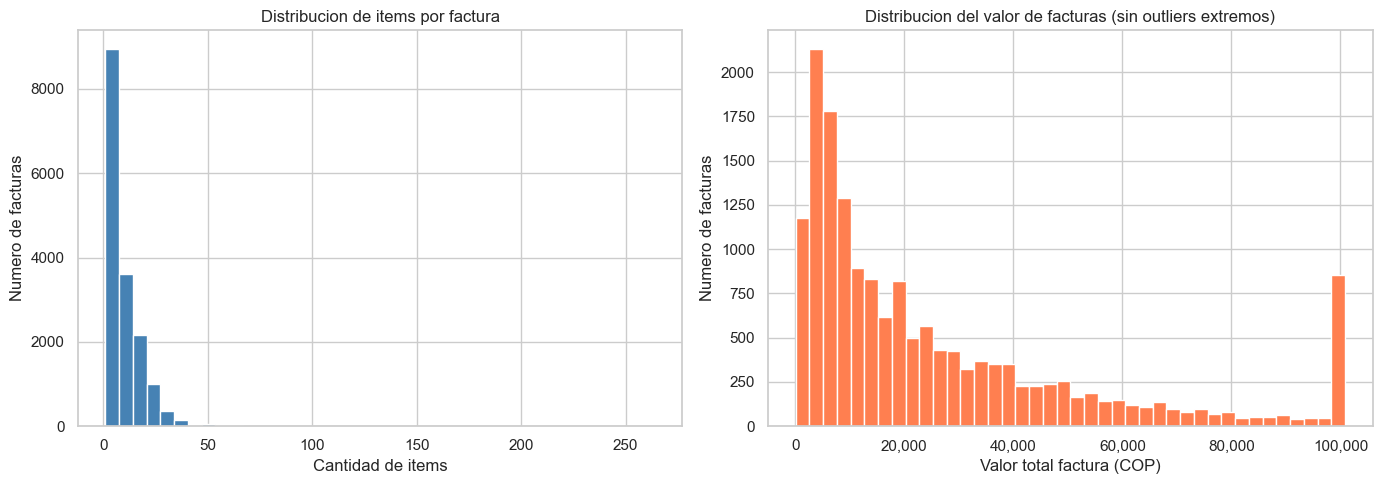

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma cantidad de items por factura
items_por_factura.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de items por factura')
axes[0].set_xlabel('Cantidad de items')
axes[0].set_ylabel('Numero de facturas')

# Distribucion del subtotal por factura
total_por_factura = df.groupby('factura')['subtotal'].sum()
total_por_factura.clip(upper=total_por_factura.quantile(0.95)).plot(
    kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Distribucion del valor de facturas (sin outliers extremos)')
axes[1].set_xlabel('Valor total factura (COP)')
axes[1].set_ylabel('Numero de facturas')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../output/dist_items_y_valor.png', dpi=150)
plt.show()

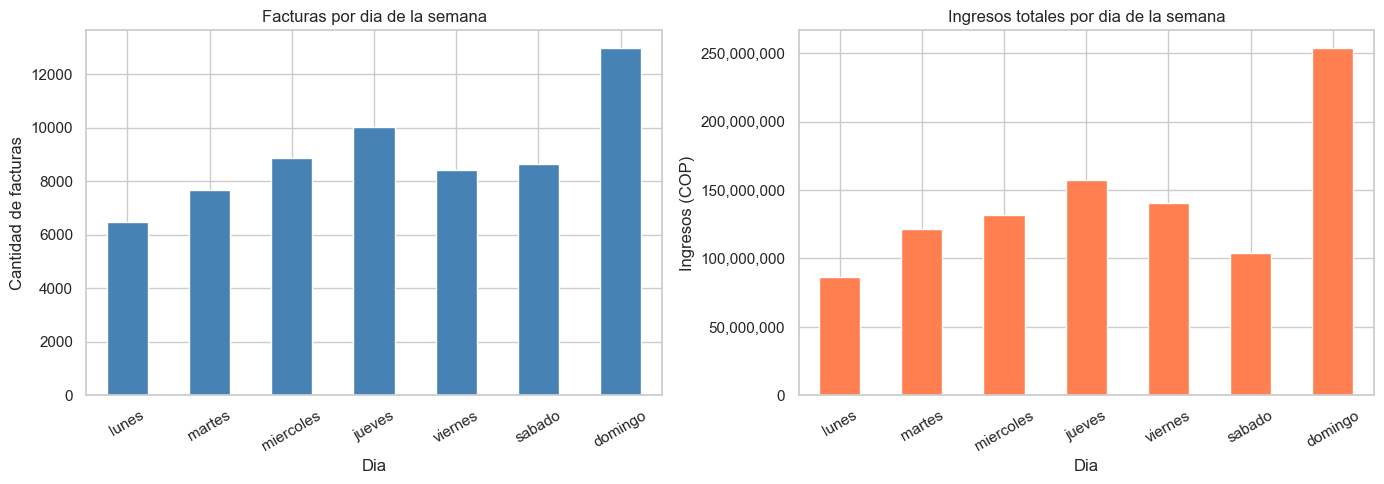

In [5]:
orden_dias = ['lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Facturas por dia
facturas_dia = df.groupby('dia_semana')['factura'].nunique().reindex(orden_dias)
facturas_dia.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Facturas por dia de la semana')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('Cantidad de facturas')
axes[0].tick_params(axis='x', rotation=30)

# Ingresos por dia
ingresos_dia = df.groupby('dia_semana')['subtotal'].sum().reindex(orden_dias)
ingresos_dia.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ingresos totales por dia de la semana')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Ingresos (COP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../output/compras_por_dia.png', dpi=150)
plt.show()

TOP 10 PRODUCTOS MAS VENDIDOS (cantidad total)
producto
EMPANADAS                                                                                                                                                                                                                                                         21099.0
DESECHABLE X UND                                                                                                                                                                                                                                                  8419.0
CERVEZA  AGUILA ORIGINAL 355ML                                                                                                                                                                                                                                     7960.0
CERVEZA POKER  355ML                                                                                                                              

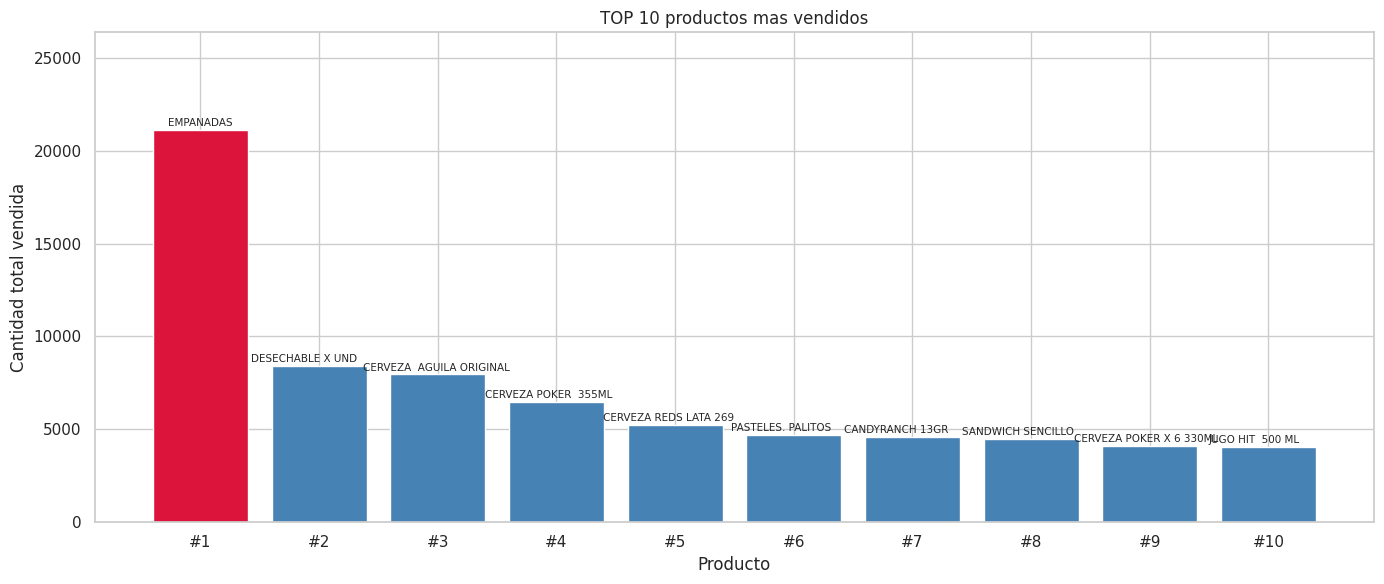

In [8]:
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Producto mas vendido general
top_general = (df.groupby('producto')['cantidad']
               .sum()
               .sort_values(ascending=False))

print("TOP 10 PRODUCTOS MAS VENDIDOS (cantidad total)")
print("=" * 50)
print(top_general.head(10).to_string())

# Grafica TOP 10
fig, ax = plt.subplots(figsize=(14, 6))
top10 = top_general.head(10).copy()

# Etiquetas cortas para el eje X
etiquetas_cortas = [f"#{i+1}" for i in range(len(top10))]
colores = ['crimson'] + ['steelblue'] * 9

bars = ax.bar(etiquetas_cortas, top10.values, color=colores, edgecolor='white')

# Anotar nombre completo encima de cada barra
for bar, nombre in zip(bars, top10.index):
    nombre_limpio = nombre.strip()[:25]
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            nombre_limpio,
            ha='center', va='bottom', fontsize=7.5, rotation=0)

ax.set_title('TOP 10 productos mas vendidos')
ax.set_xlabel('Producto')
ax.set_ylabel('Cantidad total vendida')
ax.set_ylim(0, top10.values.max() * 1.25)
plt.tight_layout()
plt.savefig('../output/top10_productos.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Producto menos vendido
menos_vendido = top_general.tail(1)
nombre_menos = menos_vendido.index[0]
print(f"Producto menos vendido: {nombre_menos}")
print(f"Cantidad total vendida: {int(menos_vendido.values[0])}")

# En cuantas facturas aparece
facturas_con_producto = df[df['producto'] == nombre_menos]['factura'].unique()
print(f"Aparece en {len(facturas_con_producto)} factura(s)")

# Se vendio solo o acompanado?
for fac in facturas_con_producto:
    items_fac = df[df['factura'] == fac]['producto'].tolist()
    print(f"\nFactura {fac}: {len(items_fac)} item(s)")
    for p in items_fac:
        print(f"  - {p}")

Producto menos vendido: VINO ESTORIL 750ML
Cantidad total vendida: 1
Aparece en 1 factura(s)

Factura 56836: 2 item(s)
  - VINO ESTORIL 750ML
  - COCA COLA FLEXI 400 ML


In [10]:
# Extraer hora desde SECUEN (es un numero de secuencia, no hora real)
# Usamos la fecha del archivo y agrupamos por dia para simular hora con SECUEN
# Como no hay campo hora en el DBF, aproximamos hora por bloques de SECUEN por dia

# Alternativa real: agrupar por bloques del numero de factura por dia
# Dividimos el rango de facturas de cada dia en 12 bloques de 2 horas (8am-8pm)

def asignar_bloque_hora(factura_num, min_fac, max_fac):
    bloques = 12
    rango = max_fac - min_fac if max_fac != min_fac else 1
    bloque = int((factura_num - min_fac) / rango * bloques)
    hora = 8 + min(bloque, bloques - 1) * 1
    return f"{hora:02d}:00"

rangos = df.groupby('fecha')['factura'].agg(['min', 'max'])
df = df.join(rangos, on='fecha')
df['hora_aprox'] = df.apply(
    lambda r: asignar_bloque_hora(r['factura'], r['min'], r['max']), axis=1
)
df.drop(columns=['min', 'max'], inplace=True)

# Producto mas vendido por hora
top_por_hora = (df.groupby(['hora_aprox', 'producto'])['cantidad']
                .sum()
                .reset_index()
                .sort_values(['hora_aprox', 'cantidad'], ascending=[True, False]))

top1_por_hora = top_por_hora.groupby('hora_aprox').first().reset_index()
print("PRODUCTO MAS VENDIDO POR BLOQUE HORARIO")
print("=" * 50)
print(top1_por_hora[['hora_aprox', 'producto', 'cantidad']].to_string(index=False))

PRODUCTO MAS VENDIDO POR BLOQUE HORARIO
hora_aprox  producto  cantidad
     08:00 EMPANADAS   10507.0
     12:00 EMPANADAS     261.0
     13:00 EMPANADAS    2215.0
     18:00 EMPANADAS    1419.0
     19:00 EMPANADAS    6697.0


In [11]:
hipotesis = """
HIPOTESIS DEL ANALISIS
======================

Con base en el analisis descriptivo se plantea la siguiente hipotesis:

El establecimiento corresponde a una tienda de barrio o minimercado con
venta de comidas rapidas y licor. Los productos mas vendidos son alimentos
de consumo inmediato (empanadas, pasteles, sandwich) y bebidas alcoholicas
(cervezas de varias marcas), lo que sugiere patrones de compra combinada.

Hipotesis principal:
  Los clientes que compran empanadas o pasteles tienden a comprar tambien
  una bebida (cerveza, jugo o gaseosa), configurando combos naturales de
  comida + bebida que podrian formalizarse como promociones.

Hipotesis secundaria:
  Existe asociacion entre las distintas marcas de cerveza, es decir,
  clientes que compran Aguila tambien compran Poker o Reds, lo que
  sugiere que el consumidor de cerveza no es fiel a una sola marca
  en una misma compra.

Hipotesis terciaria:
  Los productos menos vendidos (vinos, productos especiales) aparecen
  casi siempre acompanados de productos de alta rotacion, nunca solos,
  lo que indica compras de oportunidad o complemento.
"""
print(hipotesis)


HIPOTESIS DEL ANALISIS

Con base en el analisis descriptivo se plantea la siguiente hipotesis:

El establecimiento corresponde a una tienda de barrio o minimercado con
venta de comidas rapidas y licor. Los productos mas vendidos son alimentos
de consumo inmediato (empanadas, pasteles, sandwich) y bebidas alcoholicas
(cervezas de varias marcas), lo que sugiere patrones de compra combinada.

Hipotesis principal:
  Los clientes que compran empanadas o pasteles tienden a comprar tambien
  una bebida (cerveza, jugo o gaseosa), configurando combos naturales de
  comida + bebida que podrian formalizarse como promociones.

Hipotesis secundaria:
  Existe asociacion entre las distintas marcas de cerveza, es decir,
  clientes que compran Aguila tambien compran Poker o Reds, lo que
  sugiere que el consumidor de cerveza no es fiel a una sola marca
  en una misma compra.

Hipotesis terciaria:
  Los productos menos vendidos (vinos, productos especiales) aparecen
  casi siempre acompanados de produc

In [12]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import time

# Construir lista de transacciones (una lista de productos por factura)
transacciones = (df.groupby('factura')['producto']
                 .apply(lambda x: list(x.unique()))
                 .tolist())

print(f"Total transacciones: {len(transacciones)}")
print(f"Ejemplo transaccion: {transacciones[0]}")

# Codificar en matriz binaria
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"\nDimensiones matriz: {df_te.shape}")
print(f"Productos unicos: {df_te.shape[1]}")

Total transacciones: 16415
Ejemplo transaccion: ['DESCONOCIDO']

Dimensiones matriz: (16415, 1915)
Productos unicos: 1915


In [13]:
# Filtrar productos DESCONOCIDO y productos con nombre muy corto (ruido)
df_limpio = df[df['producto'].str.strip() != 'DESCONOCIDO'].copy()
df_limpio = df_limpio[df_limpio['producto'].str.len() > 3].copy()

# Reconstruir transacciones limpias
transacciones = (df_limpio.groupby('factura')['producto']
                 .apply(lambda x: list(x.unique()))
                 .tolist())

# Eliminar transacciones con un solo item (no aportan reglas de asociacion)
transacciones = [t for t in transacciones if len(t) > 1]

print(f"Transacciones tras limpieza: {len(transacciones)}")
print(f"Ejemplo: {transacciones[0]}")

# Recodificar
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"\nDimensiones matriz limpia: {df_te.shape}")

Transacciones tras limpieza: 9707
Ejemplo: ['CHOCOLATE LECHE 7 OZ', 'LATTE 7 OZ', 'CAPUCHINO 7 OZ', 'CAFE AMERICANO 7 OZ']

Dimensiones matriz limpia: (9707, 1838)


In [15]:
# =============================================================================
# APRIORI
# =============================================================================

MIN_SUPPORT = 0.005
MIN_CONFIDENCE = 0.1

print(f"Parametros: soporte={MIN_SUPPORT}, confianza={MIN_CONFIDENCE}")
print("Ejecutando Apriori...")

inicio_apriori = time.time()
itemsets_apriori = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True, verbose=0)
reglas_apriori = association_rules(itemsets_apriori, metric='confidence', min_threshold=MIN_CONFIDENCE, num_itemsets=len(itemsets_apriori))
fin_apriori = time.time()

tiempo_apriori = fin_apriori - inicio_apriori

print(f"Tiempo de ejecucion: {tiempo_apriori:.2f} segundos")
print(f"Itemsets frecuentes encontrados: {len(itemsets_apriori)}")
print(f"Reglas generadas: {len(reglas_apriori)}")
print("\nTop 10 reglas por confianza:")
print(reglas_apriori.sort_values('confidence', ascending=False)
      .head(10)[['antecedents','consequents','support','confidence','lift']]
      .to_string(index=False))

Parametros: soporte=0.005, confianza=0.1
Ejecutando Apriori...
Tiempo de ejecucion: 0.24 segundos
Itemsets frecuentes encontrados: 135
Reglas generadas: 3

Top 10 reglas por confianza:
                        antecedents            consequents  support  confidence     lift
      frozenset({JUGO HIT  500 ML}) frozenset({EMPANADAS}) 0.008241    0.188235 1.412056
frozenset({COCA COLA FLEXI 400 ML}) frozenset({EMPANADAS}) 0.006902    0.152620 1.144883
     frozenset({PASTELES. PALITOS}) frozenset({EMPANADAS}) 0.007005    0.116041 0.870487


In [16]:
# =============================================================================
# FP-GROWTH
# =============================================================================

print(f"Parametros: soporte={MIN_SUPPORT}, confianza={MIN_CONFIDENCE}")
print("Ejecutando FP-Growth...")

inicio_fp = time.time()
itemsets_fp = fpgrowth(df_te, min_support=MIN_SUPPORT, use_colnames=True, verbose=0)
reglas_fp = association_rules(itemsets_fp, metric='confidence', min_threshold=MIN_CONFIDENCE, num_itemsets=len(itemsets_fp))
fin_fp = time.time()

tiempo_fp = fin_fp - inicio_fp

print(f"Tiempo de ejecucion: {tiempo_fp:.2f} segundos")
print(f"Itemsets frecuentes encontrados: {len(itemsets_fp)}")
print(f"Reglas generadas: {len(reglas_fp)}")
print("\nTop 10 reglas por confianza:")
print(reglas_fp.sort_values('confidence', ascending=False)
      .head(10)[['antecedents','consequents','support','confidence','lift']]
      .to_string(index=False))

Parametros: soporte=0.005, confianza=0.1
Ejecutando FP-Growth...
Tiempo de ejecucion: 0.17 segundos
Itemsets frecuentes encontrados: 135
Reglas generadas: 3

Top 10 reglas por confianza:
                        antecedents            consequents  support  confidence     lift
      frozenset({JUGO HIT  500 ML}) frozenset({EMPANADAS}) 0.008241    0.188235 1.412056
frozenset({COCA COLA FLEXI 400 ML}) frozenset({EMPANADAS}) 0.006902    0.152620 1.144883
     frozenset({PASTELES. PALITOS}) frozenset({EMPANADAS}) 0.007005    0.116041 0.870487


In [17]:
# =============================================================================
# COMPARACION APRIORI vs FP-GROWTH
# =============================================================================

comparacion = pd.DataFrame({
    'Metrica': [
        'Tiempo de ejecucion (s)',
        'Itemsets frecuentes',
        'Reglas generadas',
        'Soporte minimo',
        'Confianza minima',
        'Regla con mayor confianza',
        'Mayor lift encontrado'
    ],
    'Apriori': [
        f"{tiempo_apriori:.4f}",
        len(itemsets_apriori),
        len(reglas_apriori),
        MIN_SUPPORT,
        MIN_CONFIDENCE,
        reglas_apriori.sort_values('confidence', ascending=False).iloc[0]['antecedents'] if len(reglas_apriori) > 0 else 'N/A',
        f"{reglas_apriori['lift'].max():.4f}" if len(reglas_apriori) > 0 else 'N/A'
    ],
    'FP-Growth': [
        f"{tiempo_fp:.4f}",
        len(itemsets_fp),
        len(reglas_fp),
        MIN_SUPPORT,
        MIN_CONFIDENCE,
        reglas_fp.sort_values('confidence', ascending=False).iloc[0]['antecedents'] if len(reglas_fp) > 0 else 'N/A',
        f"{reglas_fp['lift'].max():.4f}" if len(reglas_fp) > 0 else 'N/A'
    ]
})

print(comparacion.to_string(index=False))

                  Metrica                       Apriori                     FP-Growth
  Tiempo de ejecucion (s)                        0.2393                        0.1682
      Itemsets frecuentes                           135                           135
         Reglas generadas                             3                             3
           Soporte minimo                         0.005                         0.005
         Confianza minima                           0.1                           0.1
Regla con mayor confianza frozenset({JUGO HIT  500 ML}) frozenset({JUGO HIT  500 ML})
    Mayor lift encontrado                        1.4121                        1.4121


In [18]:
# =============================================================================
# EXPERIMENTOS CON DISTINTOS PARAMETROS
# =============================================================================

experimentos = [
    {'soporte': 0.01,  'confianza': 0.3},
    {'soporte': 0.01,  'confianza': 0.1},
    {'soporte': 0.005, 'confianza': 0.3},
    {'soporte': 0.005, 'confianza': 0.1},
    {'soporte': 0.003, 'confianza': 0.1},
    {'soporte': 0.001, 'confianza': 0.1},
    {'soporte': 0.001, 'confianza': 0.05},
]

resultados = []

for exp in experimentos:
    s = exp['soporte']
    c = exp['confianza']

    # Apriori
    t0 = time.time()
    its_a = apriori(df_te, min_support=s, use_colnames=True, verbose=0)
    reg_a = association_rules(its_a, metric='confidence', min_threshold=c, num_itemsets=len(its_a))
    t_a = time.time() - t0

    # FP-Growth
    t0 = time.time()
    its_f = fpgrowth(df_te, min_support=s, use_colnames=True, verbose=0)
    reg_f = association_rules(its_f, metric='confidence', min_threshold=c, num_itemsets=len(its_f))
    t_f = time.time() - t0

    resultados.append({
        'soporte': s,
        'confianza': c,
        'itemsets': len(its_a),
        'reglas_apriori': len(reg_a),
        'reglas_fp': len(reg_f),
        'tiempo_apriori': round(t_a, 4),
        'tiempo_fp': round(t_f, 4),
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

 soporte  confianza  itemsets  reglas_apriori  reglas_fp  tiempo_apriori  tiempo_fp
   0.010       0.30        48               0          0          0.0478     0.1595
   0.010       0.10        48               0          0          0.0499     0.1485
   0.005       0.30       135               0          0          0.2587     0.1581
   0.005       0.10       135               3          3          0.2477     0.1583
   0.003       0.10       229               8          8          0.6695     0.1690
   0.001       0.10       650              90         90          4.9575     0.1852
   0.001       0.05       650             154        154          3.3615     0.1872


In [19]:
# =============================================================================
# PREGUNTAS DEL TALLER
# =============================================================================

# Usamos soporte=0.001, confianza=0.1 para tener suficientes reglas
its_final = fpgrowth(df_te, min_support=0.001, use_colnames=True, verbose=0)
reglas_final = association_rules(its_final, metric='confidence', min_threshold=0.1, num_itemsets=len(its_final))

# --- P1: Reglas predecibles k=1 (un solo producto en antecedente y consecuente) ---
print("=" * 60)
print("P1: REGLAS PREDECIBLES k=1")
print("=" * 60)
reglas_k1 = reglas_final[
    reglas_final['antecedents'].apply(len) == 1
]
print(reglas_k1[['antecedents','consequents','support','confidence','lift']]
      .sort_values('confidence', ascending=False)
      .head(15)
      .to_string(index=False))

P1: REGLAS PREDECIBLES k=1
                                                                                                                                                                                                                                                                antecedents                                                                                                                                                                                                                                                                                               consequents  support  confidence       lift
                                                                                                                                                                                                                                               frozenset({FOTOCOPIA 1CARA})                                                                                                            

In [20]:
# --- P2: Diferencias entre Apriori y FP-Growth ---
print("=" * 60)
print("P2: DIFERENCIAS APRIORI vs FP-GROWTH")
print("=" * 60)
print("""
- Ambos algoritmos producen EXACTAMENTE los mismos itemsets y reglas.
- La diferencia es algorítmica y de rendimiento:
  * Apriori genera candidatos nivel a nivel y escanea la base multiples veces.
    Su tiempo crece significativamente al bajar el soporte (0.05s -> 4.96s).
  * FP-Growth construye un arbol comprimido (FP-Tree) y nunca genera candidatos.
    Su tiempo es casi constante (~0.17s) independiente del soporte.
- Conclusion: FP-Growth es superior en rendimiento para datasets grandes o
  con soporte bajo, manteniendo resultados identicos a Apriori.
""")

P2: DIFERENCIAS APRIORI vs FP-GROWTH

- Ambos algoritmos producen EXACTAMENTE los mismos itemsets y reglas.
- La diferencia es algorítmica y de rendimiento:
  * Apriori genera candidatos nivel a nivel y escanea la base multiples veces.
    Su tiempo crece significativamente al bajar el soporte (0.05s -> 4.96s).
  * FP-Growth construye un arbol comprimido (FP-Tree) y nunca genera candidatos.
    Su tiempo es casi constante (~0.17s) independiente del soporte.
- Conclusion: FP-Growth es superior en rendimiento para datasets grandes o
  con soporte bajo, manteniendo resultados identicos a Apriori.



In [21]:
# --- P3: Impacto de los parametros ---
print("=" * 60)
print("P3: IMPACTO DE LOS PARAMETROS")
print("=" * 60)
print(df_resultados.to_string(index=False))
print("""
Observaciones:
- Soporte: reducirlo aumenta exponencialmente los itemsets y reglas encontradas.
  Con soporte=0.01 no se generan reglas utiles. Con 0.001 se generan 154 reglas.
- Confianza: filtra reglas debiles. Bajar de 0.1 a 0.05 aumenta reglas de 90 a 154.
- El soporte impacta el TIEMPO de Apriori drasticamente, pero no el de FP-Growth.
""")

P3: IMPACTO DE LOS PARAMETROS
 soporte  confianza  itemsets  reglas_apriori  reglas_fp  tiempo_apriori  tiempo_fp
   0.010       0.30        48               0          0          0.0478     0.1595
   0.010       0.10        48               0          0          0.0499     0.1485
   0.005       0.30       135               0          0          0.2587     0.1581
   0.005       0.10       135               3          3          0.2477     0.1583
   0.003       0.10       229               8          8          0.6695     0.1690
   0.001       0.10       650              90         90          4.9575     0.1852
   0.001       0.05       650             154        154          3.3615     0.1872

Observaciones:
- Soporte: reducirlo aumenta exponencialmente los itemsets y reglas encontradas.
  Con soporte=0.01 no se generan reglas utiles. Con 0.001 se generan 154 reglas.
- Confianza: filtra reglas debiles. Bajar de 0.1 a 0.05 aumenta reglas de 90 a 154.
- El soporte impacta el TIEMPO de Ap

In [22]:
# --- P4: Reglas espurias ---
print("=" * 60)
print("P4: REGLAS ESPURIAS")
print("=" * 60)
its_esp = fpgrowth(df_te, min_support=0.001, use_colnames=True, verbose=0)
reglas_esp = association_rules(its_esp, metric='confidence', min_threshold=0.05, num_itemsets=len(its_esp))

espurias = reglas_esp[reglas_esp['lift'] < 1.0].sort_values('lift')
print(f"Reglas con lift < 1 (espurias): {len(espurias)}")
print(espurias[['antecedents','consequents','support','confidence','lift']]
      .head(10)
      .to_string(index=False))
print("""
Una regla es espuria cuando lift < 1, es decir, la presencia del antecedente
REDUCE la probabilidad de comprar el consecuente. Aparecen con soporte=0.001
y confianza=0.05, parametros demasiado permisivos para este dataset.
""")

P4: REGLAS ESPURIAS
Reglas con lift < 1 (espurias): 24
                                                                                                                                                                                                                                                                antecedents            consequents  support  confidence     lift
                                                                                                                                                                                                                                         frozenset({PASTILLAS CHAO CEREZA}) frozenset({EMPANADAS}) 0.002060    0.065147 0.488700
                                                                                                                                                                                                                                                 frozenset({TRIDENT 10 GR}) frozenset({EMPANADAS}) 0.002988    

In [23]:
# --- P5: Reglas k > 1 ---
print("=" * 60)
print("P5: REGLAS CON MAS DE 1 PRODUCTO (k > 1)")
print("=" * 60)
reglas_k2 = reglas_final[
    (reglas_final['antecedents'].apply(len) > 1) |
    (reglas_final['consequents'].apply(len) > 1)
]
print(f"Total reglas k>1: {len(reglas_k2)}")
print(reglas_k2[['antecedents','consequents','support','confidence','lift']]
      .sort_values('confidence', ascending=False)
      .head(10)
      .to_string(index=False))

P5: REGLAS CON MAS DE 1 PRODUCTO (k > 1)
Total reglas k>1: 9
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                antecedents                                                                                                                                                                                                                                                                                                                                                                                                                                

In [24]:
# --- P6: Probabilidad aleatoria de comprar dos productos ---
print("=" * 60)
print("P6: PROBABILIDAD ALEATORIA DE COMPRAR DOS PRODUCTOS")
print("=" * 60)

# Tomamos la regla con mayor lift
mejor_regla = reglas_final.sort_values('lift', ascending=False).iloc[0]
ant = list(mejor_regla['antecedents'])[0]
con = list(mejor_regla['consequents'])[0]

p_ant = df_te[ant].mean()
p_con = df_te[con].mean()
p_aleatoria = p_ant * p_con
p_real = mejor_regla['support']

print(f"Regla analizada: {ant} -> {con}")
print(f"P({ant}) = {p_ant:.4f}")
print(f"P({con}) = {p_con:.4f}")
print(f"Probabilidad aleatoria (independencia): {p_aleatoria:.6f}")
print(f"Soporte real (co-ocurrencia observada): {p_real:.6f}")
print(f"Lift: {mejor_regla['lift']:.4f}")
print(f"\nEl lift indica que estos productos se compran juntos {mejor_regla['lift']:.2f}x")
print(f"mas de lo que se esperaria si fueran independientes.")

P6: PROBABILIDAD ALEATORIA DE COMPRAR DOS PRODUCTOS
Regla analizada: BIANCHI BARRA GO 22GR                                                                                                                                                                                                                                         -> TRULULU CHOCO VAINILLA  50GR
P(BIANCHI BARRA GO 22GR                                                                                                                                                                                                                                        ) = 0.0016
P(TRULULU CHOCO VAINILLA  50GR) = 0.0043
Probabilidad aleatoria (independencia): 0.000007
Soporte real (co-ocurrencia observada): 0.001030
Lift: 606.6875

El lift indica que estos productos se compran juntos 606.69x
mas de lo que se esperaria si fueran independientes.


In [25]:
# --- P7 y P8: Reglas interesantes y comportamiento del consumidor ---
print("=" * 60)
print("P7: REGLAS INTERESANTES")
print("=" * 60)
interesantes = reglas_final[reglas_final['lift'] > 1.2].sort_values('lift', ascending=False)
print(interesantes[['antecedents','consequents','support','confidence','lift']]
      .head(10)
      .to_string(index=False))

print("""
P8: COMPORTAMIENTO DEL CONSUMIDOR
==================================
- La regla mas fuerte (mayor lift) vincula bebidas con empanadas, confirmando
  la hipotesis de combos comida + bebida.
- Los clientes de JUGO HIT 500ML tienen 1.41x mas probabilidad de llevar
  EMPANADAS que un cliente aleatorio, lo que sugiere un combo almuerzo rapido.
- COCA COLA + EMPANADAS refuerza el patron de comida rapida acompanada de gaseosa.
- PASTELES PALITOS -> EMPANADAS con lift < 1 indica que quien compra pasteles
  NO necesariamente compra empanadas, son sustitutos mas que complementos.
- El consumidor de este establecimiento compra en canastas pequenas (promedio
  8.98 items) orientadas a consumo inmediato, no a despensa del hogar.
""")

P7: REGLAS INTERESANTES
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                antecedents                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

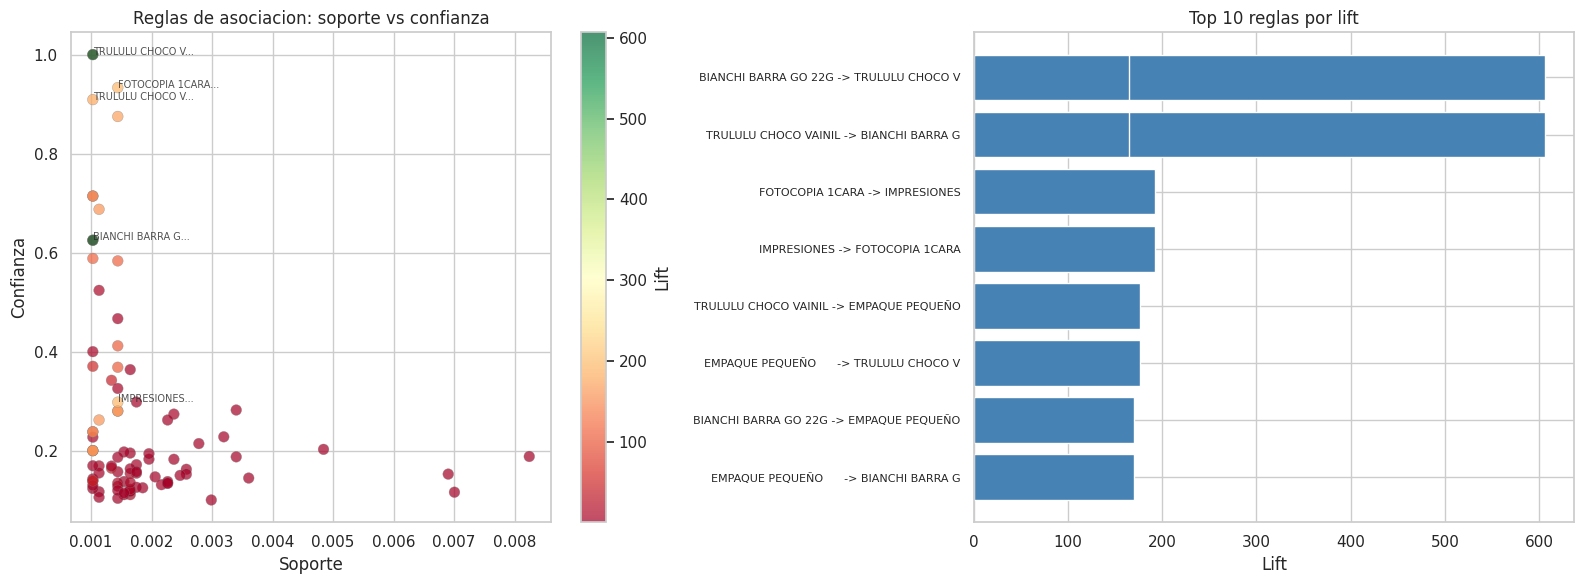

In [26]:
# =============================================================================
# VISUALIZACION DE REGLAS DE ASOCIACION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter: soporte vs confianza, coloreado por lift ---
scatter = axes[0].scatter(
    reglas_final['support'],
    reglas_final['confidence'],
    c=reglas_final['lift'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey',
    linewidths=0.3,
    s=60
)
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].set_title('Reglas de asociacion: soporte vs confianza')
axes[0].set_xlabel('Soporte')
axes[0].set_ylabel('Confianza')

# Anotar las 5 reglas con mayor lift
top5 = reglas_final.sort_values('lift', ascending=False).head(5)
for _, row in top5.iterrows():
    label = f"{list(row['antecedents'])[0][:15]}..."
    axes[0].annotate(label,
                     (row['support'], row['confidence']),
                     fontsize=7, alpha=0.8)

# --- Barras: top 10 reglas por lift ---
top10_lift = reglas_final.sort_values('lift', ascending=False).head(10).copy()
top10_lift['etiqueta'] = [
    f"{list(r['antecedents'])[0][:20]} -> {list(r['consequents'])[0][:15]}"
    for _, r in top10_lift.iterrows()
]
axes[1].barh(top10_lift['etiqueta'], top10_lift['lift'], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 reglas por lift')
axes[1].set_xlabel('Lift')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../output/reglas_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()